## Closing the water balance + comparing data in Budyko


Different datasets were downloaded and used to close the water balance and do Kalman Filtering and smoothing. 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# useful imports
# useful imports
from scipy.stats import norm#the normal distribution
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# Part 1: Errors in water balance data

#### Precipitation data

Three precipitation time-series used are: `manning_imerg_precip_hourly` (precipitation from [GPM IMERG](https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V07)), `manning_ERA5_precip_daily` (precipitation from [ERA5](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_DAILY_AGGR)), `manning_chirps_precip_daily` (precipitation from [CHIRPS](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY)).

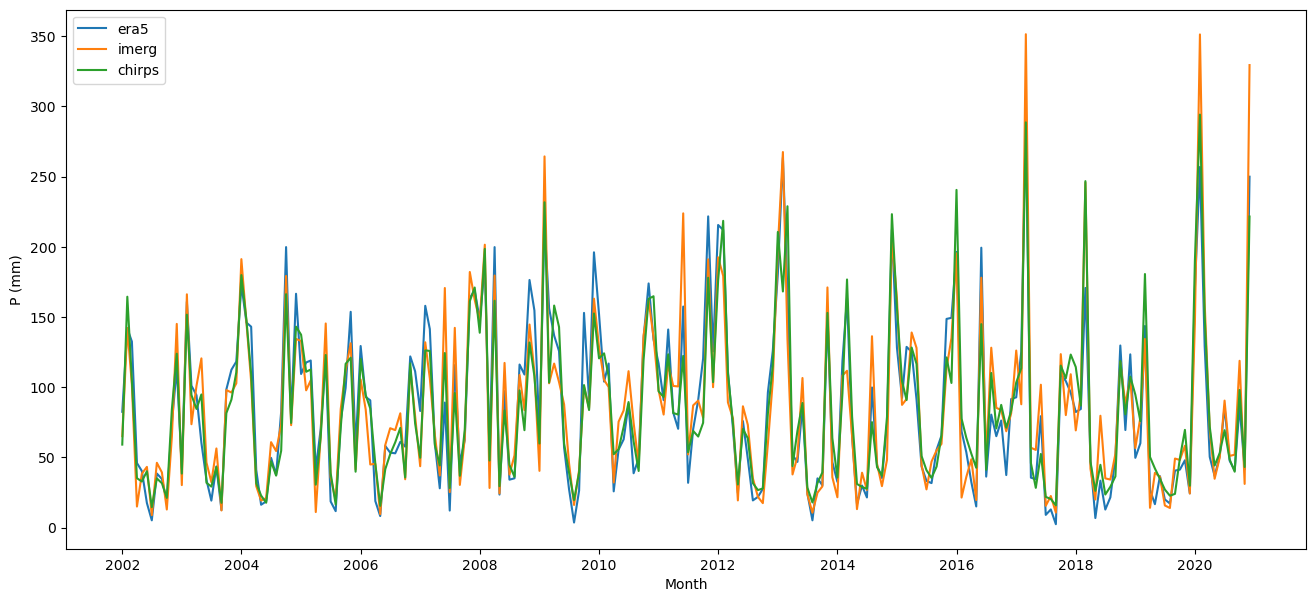

In [4]:
era5P = pd.read_csv('./Data/manning_ERA5_precip_daily.csv') # m/day 
chirps = pd.read_csv('./Data/manning_chirps_precip_daily.csv') # mm/day
imerg = pd.read_csv('./Data/manning_IMERG_precip_hourly.csv') # mm/hr


era5P['date'] = pd.to_datetime(era5P['system:index'], format='%Y%m%d')
era5P.set_index('date', inplace=True)
era5P.drop(columns=['system:index'], inplace=True)
era5P['total_precipitation_sum'] = era5P['total_precipitation_sum'] * 1000 # mm/day
era5P_monthly = era5P.resample('MS').sum() # mm/month
era5P.head()


chirps['date'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps.set_index('date', inplace=True)
chirps.drop(columns=['system:index'], inplace=True)
chirps_monthly = chirps.resample('MS').sum() # mm/month
chirps.head()   

imerg['date'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
imerg.set_index('date', inplace=True)
imerg.drop(columns=['system:index'], inplace=True)
imerg = imerg.resample('D').sum() / 2 # mm/day
imerg_monthly = imerg.resample('MS').sum() # mm/month

start_date = '2002-01-01'
end_date = '2020-12-31'

imerg_monthly = imerg_monthly.loc[start_date:end_date]
era5P_monthly = era5P_monthly.loc[start_date:end_date]
chirps_monthly = chirps_monthly.loc[start_date:end_date]


plt.figure(figsize=(16,7))
plt.plot(era5P_monthly['total_precipitation_sum'], label='era5')
plt.plot(imerg_monthly['precipitation'], label='imerg')

plt.plot(chirps_monthly['precipitation'], label='chirps')
plt.legend()
plt.xlabel('Month') 
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12

imerg.head()

# Read and plot the monthly precipitation data
PObs1 = imerg_monthly['precipitation'].values
PObs2 = era5P_monthly['total_precipitation_sum'].values
PObs3 = chirps_monthly['precipitation'].values



In each month, the sample mean $m$ and variance $v$ across $N$ datasets can be computed as:

$$m = \frac{1}{N}\sum_{i=1}^N x_i$$
$$v = \frac{1}{N-1}\sum_{i=1}^N (x_i - m)^2$$

If we apply these equations to the three precipitation datasets, we get monthly values of $m_P$ and $v_P$, which we interpret as mean and variance of a normal (Gaussian) distribution $\mathcal{N}(P|m_P, v_P)$ for the precipitation errors (uncertainty) in each month.

In [5]:
# Compute monthly mean mP and variance vP of precipitation
PObs1 = imerg_monthly['precipitation']
PObs2 = era5P_monthly['total_precipitation_sum']
PObs3 = chirps_monthly['precipitation']

mP = (PObs1 + PObs2 + PObs3) / 3
vP = (np.square(PObs1 - mP) + np.square(PObs2 - mP) + np.square(PObs3 - mP)) / 2
print(mP[0], vP[0])


68.87545339645352 147.133924315258


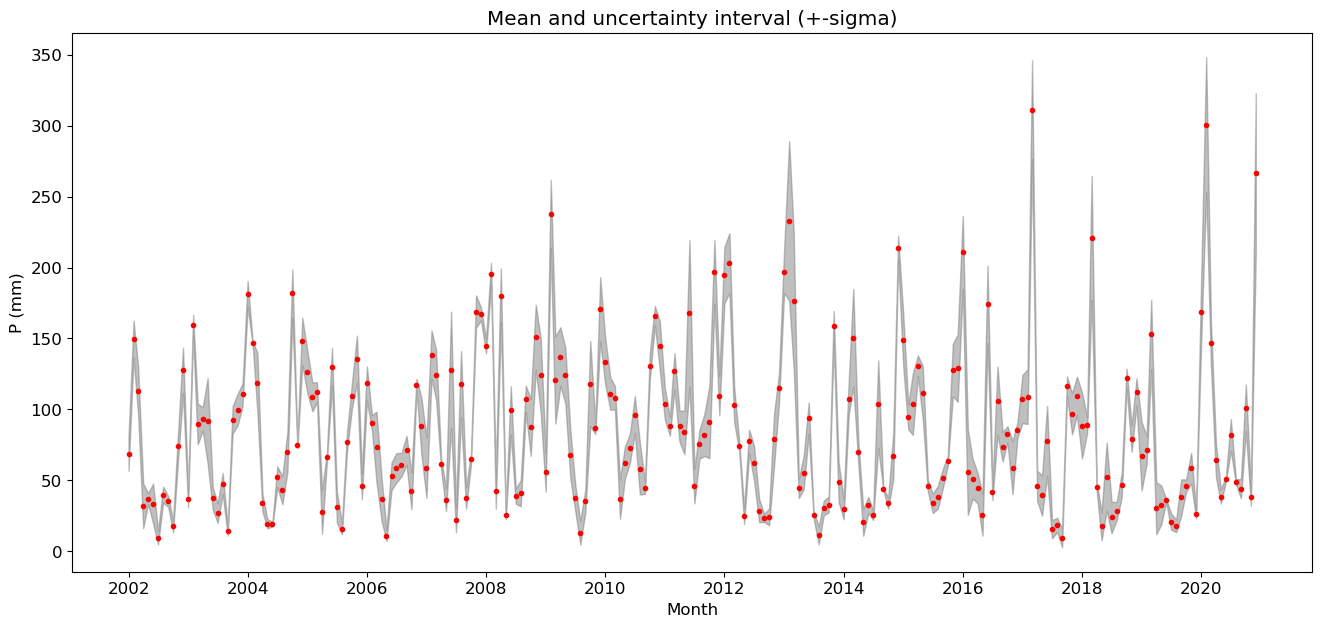

In [6]:
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation.
# The plt.fill_between() function is useful for plotting an uncertainty interval.
plt.figure(figsize=(16,7))
plt.fill_between(imerg_monthly.index, mP - np.sqrt(vP), mP + np.sqrt(vP), color='grey', alpha=0.5)
plt.plot(mP, 'r.')
plt.xlabel('Month')
plt.ylabel('P (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

#### Evaporation data

Four evaporation time-series are used: `manning_gldas_evap_3hour` (actual evaporation from [GLDAS](https://developers.google.com/earth-engine/datasets/catalog/NASA_GLDAS_V021_NOAH_G025_T3H)), `manning_ERA5_evap_daily` (actual evaporation from [ERA5](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR)), `manning_mod16_evap_8day` (actual evaporation from [MODIS](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD16A2GF)), `manning_CMRSETlandsat_evap_monthly` (actual evaporation from [CMRSET Landsat](https://developers.google.com/earth-engine/datasets/catalog/TERN_AET_CMRSET_LANDSAT_V2_2)).

In [7]:
# Loading the data
gldas = pd.read_csv('./Data/manning_gldas_evap_3hour.csv') # mm/s
era5E = pd.read_csv('./Data/manning_ERA5_evap_daily.csv') # m/day
mod16 = pd.read_csv('./Data/manning_mod16_evap_8day.csv') # 0.1 mm/8days
CMRSET = pd.read_csv('./Data/manning_CMRSETlandsat_evap_monthly.csv') # mm/month

# Setting the units to mm/month
gldas['date'] = pd.to_datetime(gldas['system:index'], format='A%Y%m%d_%H%M')
gldas.set_index('date', inplace=True)
gldas.drop(columns=['system:index'], inplace=True)
gldas['Evap_tavg'] = gldas['Evap_tavg'] * 10800 # mm/3hr
gldas = gldas.resample('D').sum() # mm/day
gldas_monthly = gldas.resample('MS').sum() # mm/month

era5E['date'] = pd.to_datetime(era5E['system:index'], format='%Y%m%d')
era5E.set_index('date', inplace=True)
era5E.drop(columns=['system:index'], inplace=True)
era5E['total_evaporation_sum'] = era5E['total_evaporation_sum'] * -1000 # mm/day
era5E_monthly = era5E.resample('MS').sum() # mm/month

mod16['date'] = pd.to_datetime(mod16['system:index'], format='%Y_%m_%d')
mod16.set_index('date', inplace=True)
mod16.drop(columns=['system:index'], inplace=True)
mod16['ET'] = mod16['ET'] * 0.1 # mm/8days
mod16_monthly = mod16.resample('MS').sum() # mm/month

CMRSET['date'] = pd.to_datetime(CMRSET['system:index'], format='%Y_%m_%d')
CMRSET.set_index('date', inplace=True)
CMRSET.drop(columns=['system:index'], inplace=True)
CMRSET['ETa_monthly'] = CMRSET['ETa'] * CMRSET.index.days_in_month

CMRSET_monthly = CMRSET.copy()



                 ETa  ETa_monthly
date                             
1987-05-01  1.398698    43.359652
1987-06-01  1.067470    32.024108
1987-07-01  1.249994    38.749811
1987-08-01  2.332874    72.319099
1987-09-01  2.472461    74.173820


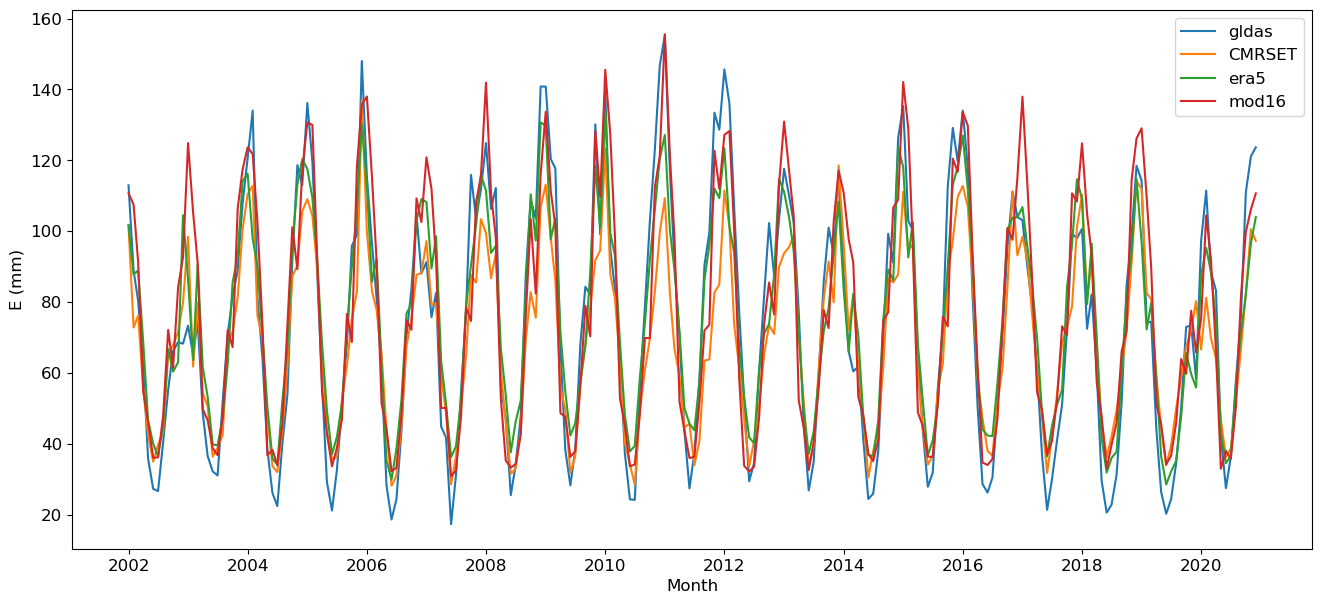

In [8]:
# Plotting the data
start_date = '2002-01-01'
end_date = '2020-12-31'

gldas_plot = gldas_monthly.loc[start_date:end_date]
era5E_plot = era5E_monthly.loc[start_date:end_date]
mod16_plot = mod16_monthly.loc[start_date:end_date]
CMRSET_plot = CMRSET_monthly.loc[start_date:end_date]
plt.figure(figsize=(16,7))
plt.plot(gldas_plot['Evap_tavg'], label='gldas')
plt.plot(CMRSET_plot['ETa_monthly'], label='CMRSET')
plt.plot(era5E_plot['total_evaporation_sum'], label='era5')
plt.plot(mod16_plot['ET'], label='mod16')

plt.legend()
plt.xlabel('Month')
plt.ylabel('E (mm)');
plt.rcParams["font.size"] = 12
print(CMRSET.head())

In [9]:
# Compute monthly mean mE and variance vE of evaporation
EObs1 = gldas_monthly['Evap_tavg']
EObs2 = era5E_monthly['total_evaporation_sum']
EObs3 = mod16_monthly['ET']
EObs4 = CMRSET_monthly['ETa_monthly']
print(EObs1[0], EObs2[0], EObs3[0], EObs4[0])
mE = (EObs1 + EObs2 + EObs3 + EObs4) / 4
vE = (np.square(EObs1 - mE) + np.square(EObs2 - mE) + np.square(EObs3 - mE) + np.square(EObs4 - mE)) / 4


130.89575147889173 92.3967701118065 122.01926616398504 43.3596519863821


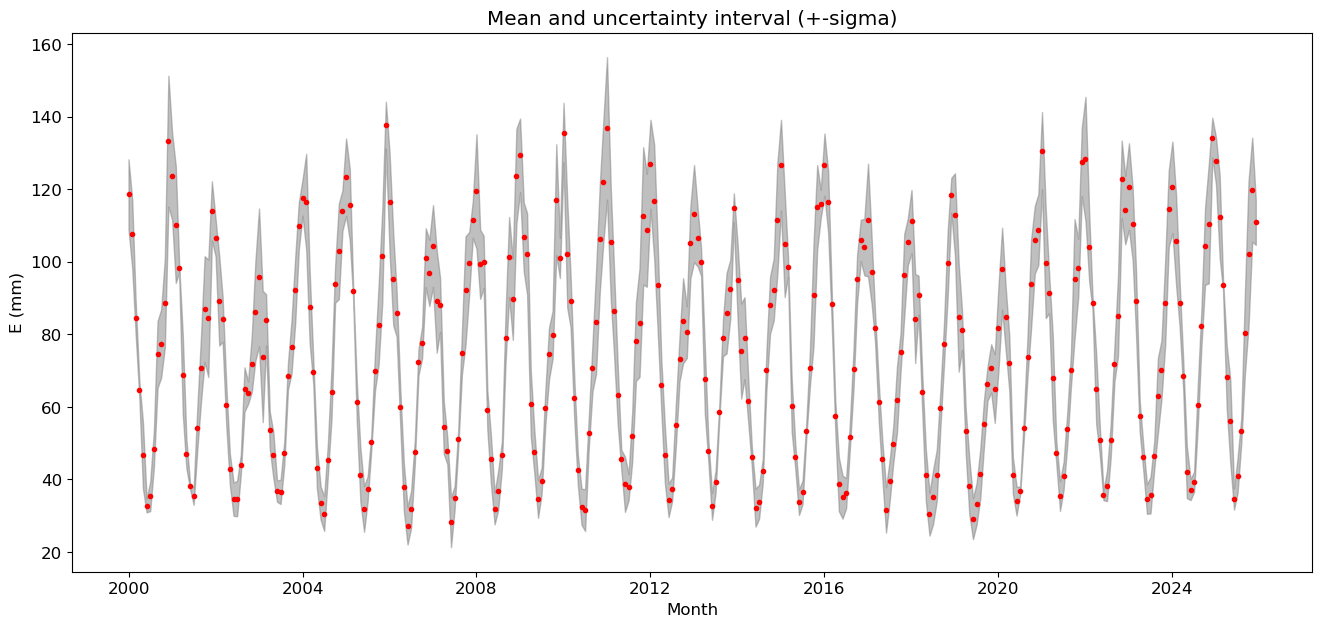

In [10]:
# Plot monthly mean and uncertainty interval (+-sigma) of evaporation
plt.figure(figsize=(16,7))
plt.fill_between(mE.index, mE - np.sqrt(vE), mE + np.sqrt(vE), color='grey', alpha=0.5)
plt.plot(mE, 'r.')
plt.xlabel('Month')
plt.ylabel('E (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');


#### River discharge data

The file `5202080_Q_Day.Cmd.txt`contains daily river discharge from a stream gauge at the river basin from GRDC. The station is Killawara. The catchment size is 6642 km^2.

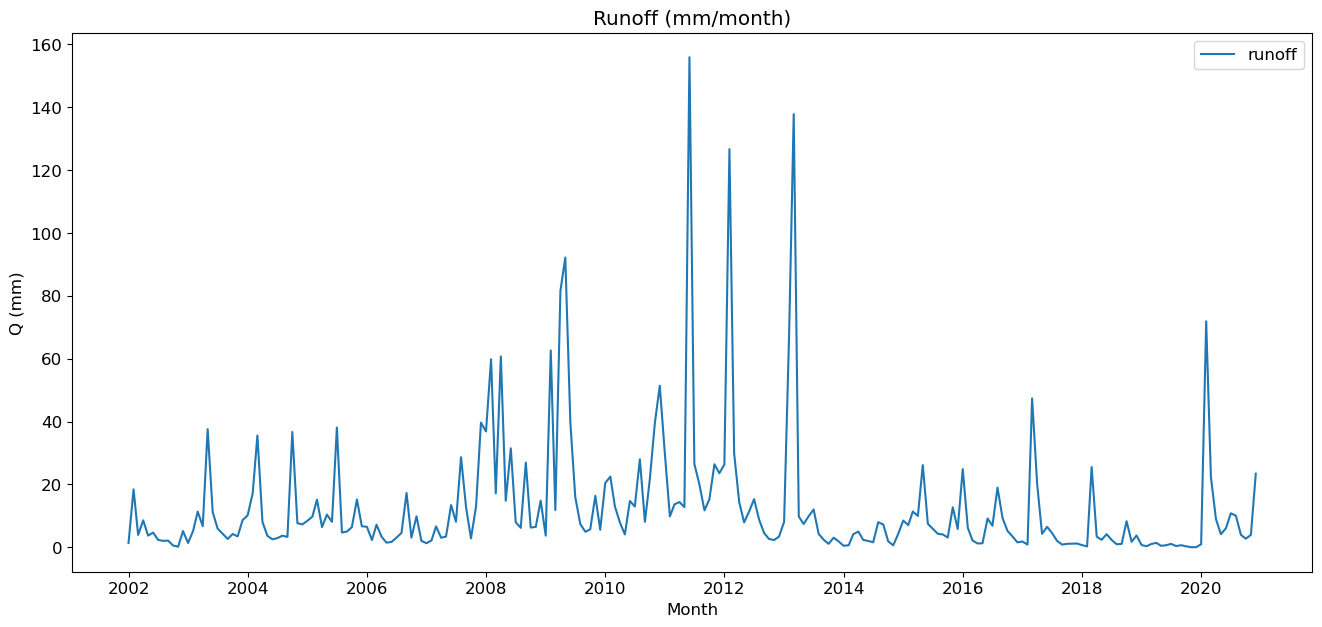

In [11]:
A_catchment = 6642 * 1e6   # m2


# Dischrarge data Killawarra station (GRDC ID: 5202080)
obs =  pd.read_csv("./Data/5202080_Q_Day.Cmd.txt",delimiter=';',skiprows=36,header=0,encoding='cp1252')
obs.columns = ['date', 'time', 'Q']
obs['date'] = pd.to_datetime(obs['date'], format='%Y-%m-%d')
obs['Q'] = pd.to_numeric(obs['Q'], errors='coerce')
obs = obs[obs['Q'] != -999]
obs.set_index('date', inplace=True)
obs.drop(columns=['time'], inplace=True)


# m3/s -> mm/day
obs['Q'] = obs['Q'] * 86400 / A_catchment * 1000
obs = obs.loc[start_date:end_date]
obs_monthly = obs.resample('MS').sum() # mm/month 

start_date = '2002-01-01'
end_date = '2025-12-31'
QObs = obs_monthly['Q']
plt.figure(figsize=(16,7))
plt.plot(QObs, label='runoff')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Q (mm)')
plt.title('Runoff (mm/month)');



Uncertainty and errors in river discharge measurements can in principle be estimated using a rating curve error analysis. Here, we will assume a 10% relative error in each month, reflecting the common situation of greater errors for measuring larger flow rates. This assumption allows us to compute a Gaussian distribution $\mathcal{N}(Q|m_Q, v_Q)$ for river discharge uncertainty in each month, where $m_Q$ is equal to the discharge measurement (unbiased measurement) and $v_Q$ is computed from the 10% error assumption.

In [12]:
# Compute monthly mean mQ and variance vQ of river discharge
mQ = QObs
vQ = np.square(0.1 * QObs)
print(mQ[0], vQ[0])


1.3361040650406504 0.01785174072618151


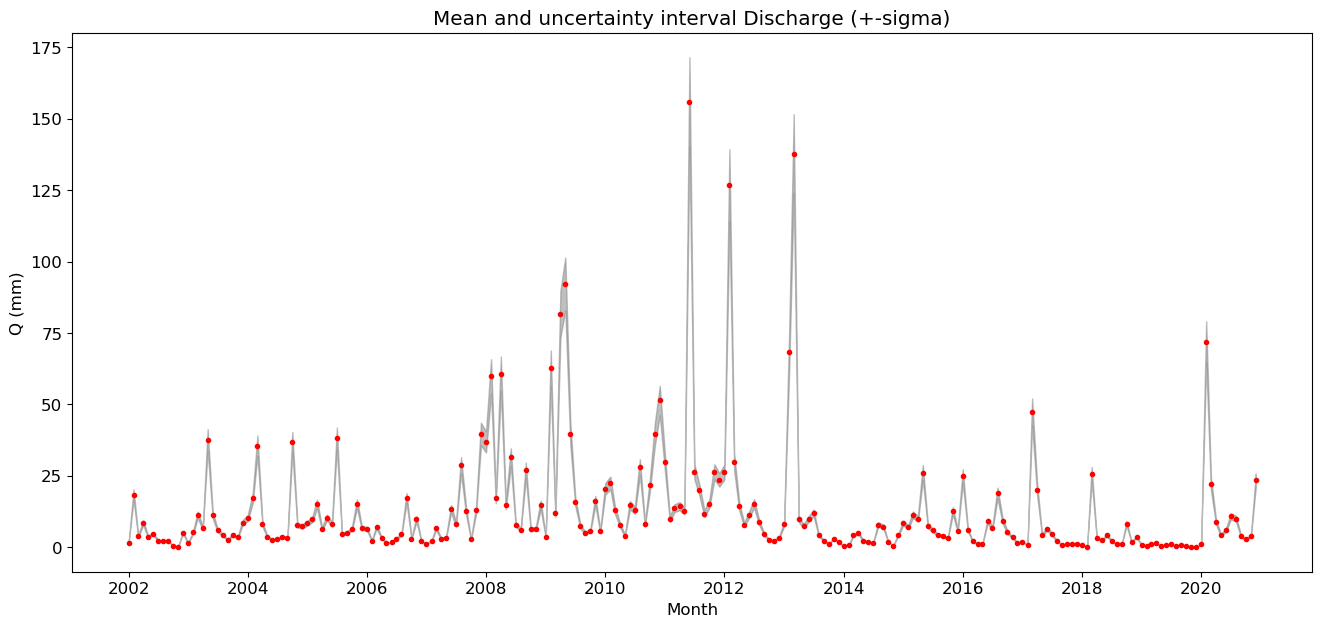

In [13]:
# Plot monthly mean and uncertainty interval (+-sigma) of river discharge
plt.figure(figsize=(16,7))
plt.fill_between(obs_monthly.index, mQ - np.sqrt(vQ), mQ + np.sqrt(vQ), color='grey', alpha=0.5)
plt.plot(mQ, 'r.')
plt.xlabel('Month')
plt.ylabel('Q (mm)')
plt.title('Mean and uncertainty interval Discharge (+-sigma)');

#### Water storage data

Monthly time-series of total water storage is provided in file `manning_grace_storage_monthly` (total water storage from the [GRACE](https://developers.google.com/earth-engine/datasets/catalog/NASA/GRACE/MASS_GRIDS_V04/LAND) dataset). This dataset also comes with an estimate of the standard error (square root of error variance) in the monthly data, provided in file `manning_grace_error_monthly` (standard error of the GRACE data). Note that the GRACE data include months with missing data; these are indicated with a nodata value of -99999. 

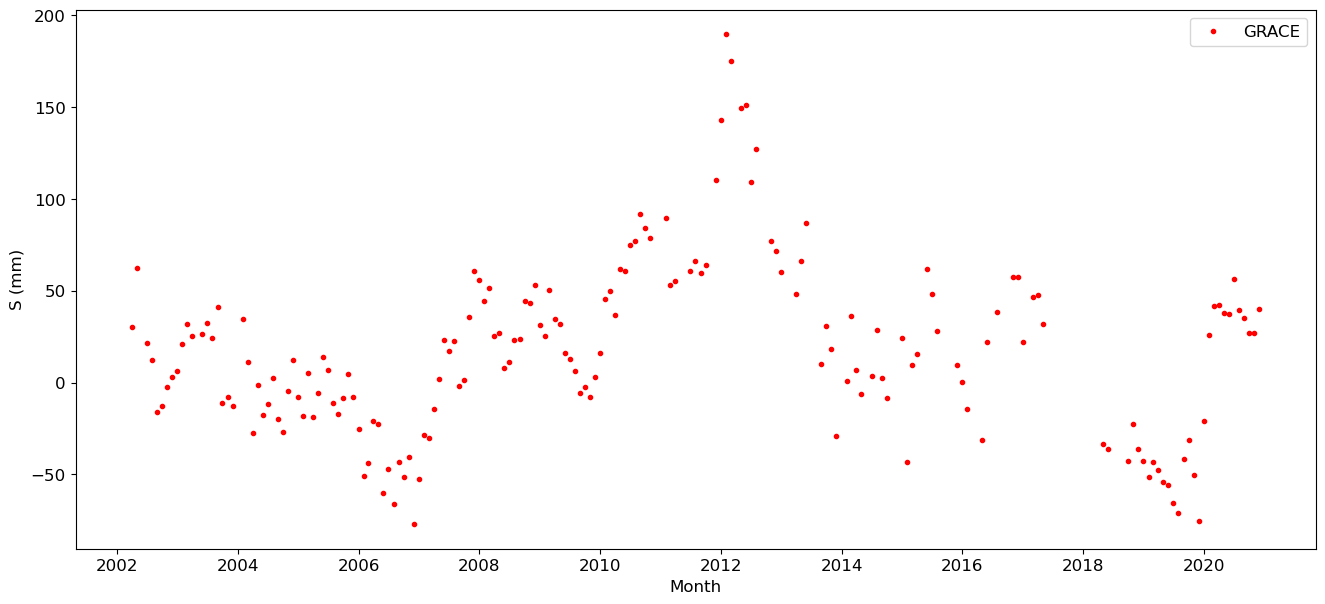

In [14]:
# Read and plot the monthly storage data
grace = pd.read_csv('./Data/manning_grace_storage_monthly.csv')      # cm
grace_error = pd.read_csv('./Data/manning_grace_error_monthly.csv')  # cm
# Set units to mm
grace['date'] = pd.to_datetime(grace['system:index'].str.split('_').str[0], format='%Y%m%d')
grace.set_index('date', inplace=True)
grace.drop(columns=['system:index'], inplace=True)
grace['lwe_thickness'] = grace['lwe_thickness'] * 10  # mm
grace_error['date'] = pd.to_datetime(grace_error['system:index'].str.split('_').str[0], format='%Y%m%d')
grace_error.set_index('date', inplace=True)
grace_error.drop(columns=['system:index'], inplace=True)
grace_error['uncertainty'] = grace_error['uncertainty'] * 10  # mm
# Put both on a monthly index
full_date_range = pd.date_range(start=era5P.index.min(), end=era5P.index.max(), freq='D')
grace = grace.reindex(full_date_range, fill_value=pd.NA).resample('MS').mean()
grace_error = grace_error.reindex(full_date_range, fill_value=pd.NA).resample('MS').mean()
# Choose one common analysis period
start_date = '2002-01-01'
end_date = '2020-12-31'
# Slice to exactly the same period
SObs = grace.loc[start_date:end_date, 'lwe_thickness'].copy()
sigmaSObs = grace_error.loc[start_date:end_date, 'uncertainty'].copy()
# Quick plot of observations only
plt.figure(figsize=(16,7))
plt.plot(SObs, 'r.', label='GRACE')
plt.legend()
plt.xlabel('Month')
plt.ylabel('S (mm)');



Since the GRACE dataset come with its own estimate of data error we will use it directly to get a Gaussian distribution $\mathcal{N}(S|m_S, v_S)$ for the uncertainty in water storage in each month. Here, $m_S$ is taken as the GRACE measurement and $v_S$ is set to the square of the GRACE standard error.

*Hint: to handle missing data values in the GRACE time-series you can for example set $m_S = 0$ and $v_S = 10^9$ (some large variance). Using a large variance represents a data value with extreme uncertainty, which is essentially equivalent to having no data for that month.*

In [15]:
# Compute monthly mean mS and variance vS of water storage
mS = SObs.copy()
vS = np.square(sigmaSObs.copy())
nodata = (SObs == -99999)
mS[nodata] = np.nan   # use nan for plotting
vS[nodata] = np.nan

print(mS.iloc[0], vS.iloc[0])


nan nan


<Figure size 1600x700 with 0 Axes>

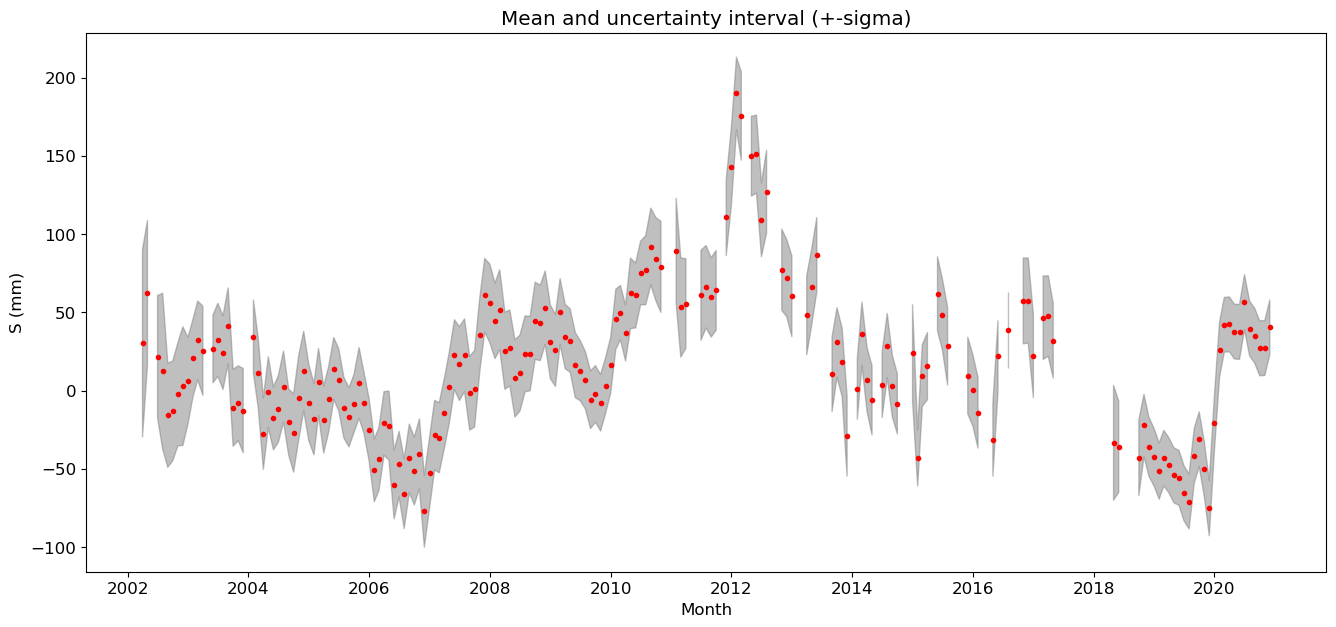

In [16]:
# Plot monthly mean and uncertainty interval (+-sigma) of water storage
plt.figure(figsize=(16,7))
plt.figure(figsize=(16,7))
x = mS.index
plt.fill_between(x,mS - np.sqrt(vS),mS + np.sqrt(vS),color='grey',alpha=0.5)
plt.plot(x, mS, 'r.')
plt.xlabel('Month')
plt.ylabel('S (mm)')
plt.title('Mean and uncertainty interval (+-sigma)')

mS[nodata] = 0
# vS[nodata] = 1e+9


# Part 2: Uncertainty propagation and Gaussian product 

In [17]:
# mP = 40.5
# vP = 10.2
# mE = 20.3
# vE = 10.9
# mQ = 5.3
# vQ = 0.5
# mS0 = 100
# vS0 = 100
# mS = 100
# vS = 100
# # 1) Propagate uncertainty to S
# # Water balance: S = S0 + P - E - Q
# mToS = mS0 + mP - mE - mQ
# vToS = vS0 + vP + vE + vQ
# print("Result for S from water balance:")
# print("mS =", mToS)
# print("vS =", vToS)
# # 2) Propagate uncertainty to P
# # Rewrite water balance:
# # P = S - S0 + E + Q
# mToP = mS - mS0 + mE + mQ
# vToP = vS + vS0 + vE + vQ
# print("\nResult for P from water balance:")
# print("mP =", mToP)
# print("vP =", vToP)

In [18]:
def gaussian_product(m1, v1, m2, v2):
    # weights
    w1 = v2 / (v1 + v2)
    w2 = v1 / (v1 + v2)  
    # new mean
    m = w1 * m1 + w2 * m2   
    # new variance
    v = (v1 * v2) / (v1 + v2)  
    return m, v

gaussian_product(10.2, 2, 5.6, 1)


(7.133333333333333, 0.6666666666666666)

In [19]:
df = pd.concat([
    mP.rename('mP'),
    vP.rename('vP'),
    mE.rename('mE'),
    vE.rename('vE'),
    mQ.rename('mQ'),
    vQ.rename('vQ'),
    mS.rename('mS'),
    vS.rename('vS')
], axis=1)

df = df.loc['2002-01-01':'2020-12-31']

# Part 3: Kalman filtering and smoothing

In [20]:
def close_water_balance(mP, vP, mE, vE, mQ, vQ, mS, vS):
    # Specify prior mean and variance for initial storage S0 (first month)
    mS0 = 0
    vS0 = 200 * 200#large variance to indicate large uncertainty
        
    # Initialize posteriors
    # We compute these in forward loop (filtering posteriors) and then update them in backward loop (smoothing posteriors)
    nt = len(mP)#number of months in time-series
    mPostP = np.zeros(nt)#posterior mean of precipitation in each month
    vPostP = np.zeros(nt)#posterior variance of precipitation in each month
    mPostE = np.zeros(nt)#etc...
    vPostE = np.zeros(nt)
    mPostQ = np.zeros(nt)
    vPostQ = np.zeros(nt)
    mPostS = np.zeros(nt)
    vPostS = np.zeros(nt)
    
    # Forward loop (filtering)
    for t in range(nt):
        # Step 1: predict - compute forward distribution to S
        if t == 0:
            mFromS = mS0
            vFromS = vS0
        else: 
            mFromS = mPostS[t-1]
            vFromS = vPostS[t-1]
        mToS = mFromS + mP[t] - mE[t] - mQ[t]
        vToS = vFromS + vP[t] + vE[t] + vQ[t]
        
        # Step 2: update - compute filtering posterior of S

        mPostS[t], vPostS[t] = gaussian_product(mToS, vToS, mS[t], vS[t])


    # Backward loop (smoothing)
    mToS, vToS = 0.0, 1e+9 #represents backward distribution to S - initialize to wide Gaussian for last month
    for t in reversed(range(nt)):
        # Step 1: smoothing posterior of S

        mPostS[t], vPostS[t] = gaussian_product(mPostS[t], vPostS[t], mToS, vToS)
        if t == 0:
            mFromS = mS0
            vFromS = vS0
        else:
            mFromS = mPostS[t-1] 
            vFromS = vPostS[t-1]
        # Step 2: posteriors of P, E, and Q
     
        mFromS, vFromS = gaussian_product(mToS, vToS, mS[t], vS[t])
        if t == 0:
            mFromS0, vFromS0 = mS0, vS0
        else:
            mFromS0, vFromS0 = mPostS[t-1], vPostS[t-1]
        mdiff = mFromS0 - mFromS
        vdiff = vFromS0 + vFromS
        mPostP[t], vPostP[t] = gaussian_product(-mdiff + mE[t] + mQ[t], vdiff + vE[t] + vQ[t], mP[t], vP[t])
        mPostE[t], vPostE[t] = gaussian_product(mdiff + mP[t] - mQ[t], vdiff + vP[t] + vQ[t], mE[t], vE[t])
        mPostQ[t], vPostQ[t] = gaussian_product(mdiff + mP[t] - mE[t], vdiff + vP[t] + vE[t], mQ[t], vQ[t])
        
        # Step 3: backward distribution to S0
        
        mToS = mFromS - mP[t] + mE[t] + mQ[t]
        vToS = vFromS + vP[t] + vE[t] + vQ[t]
        
    # After backward loop: compute posterior mean and variance of S0 (initial storage first month)
   
    mPostS0, vPostS0 = gaussian_product(mS0, vS0, mToS, vToS)
    
    # Return final water balance estimates (posterior means and variances of monthly estimates)
    return mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0


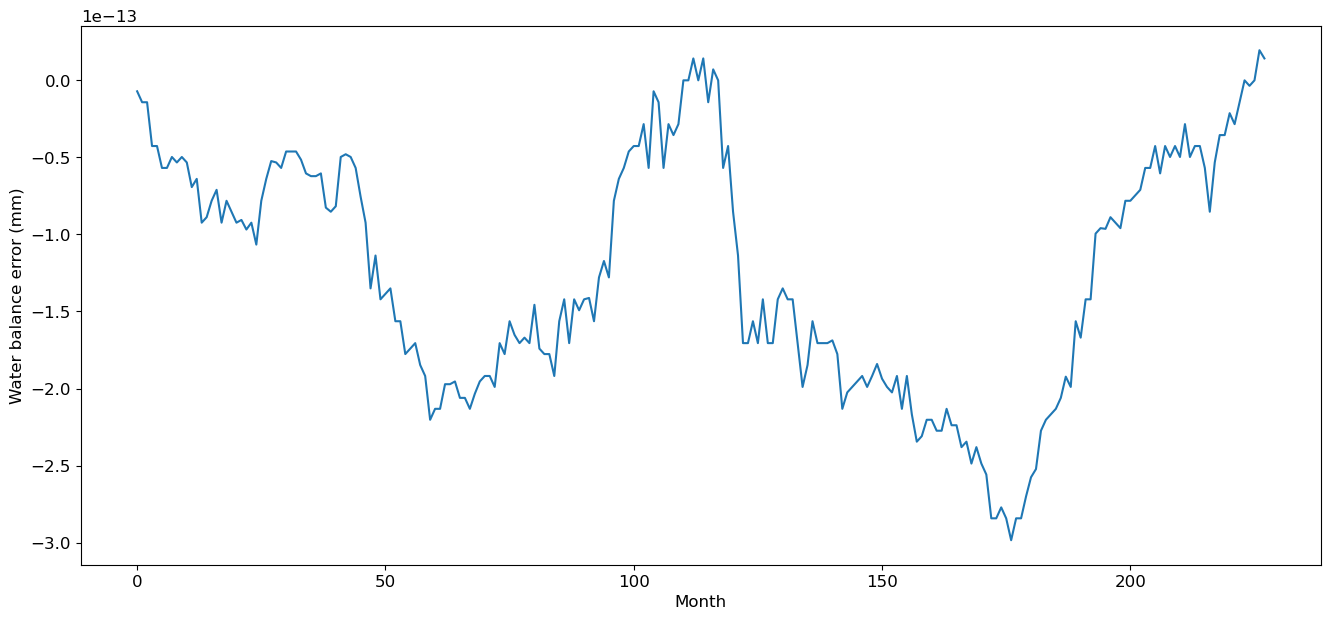

In [21]:
# # Fill the NaN values
df['mS'] = df['mS'].fillna(0)
df['vS'] = df['vS'].fillna(1e9)

mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0 = close_water_balance(
    df['mP'], df['vP'], df['mE'], df['vE'], df['mQ'], df['vQ'], df['mS'], df['vS']
)

nt = len(mP)
Swb = np.zeros(nt)
for t in range(nt):
    if t == 0:
        Swb[t] = mPostS0 + mPostP[t] - mPostE[t] - mPostQ[t]
    else:
        Swb[t] = Swb[t-1] + mPostP[t] - mPostE[t] - mPostQ[t]
wbError = Swb - mPostS

plt.figure(figsize=(16,7))
plt.plot(wbError)
plt.xlabel('Month')
plt.ylabel('Water balance error (mm)');




Finally, also plot monthly time-series of the posteriors for each variable. For example, this can be done by plotting the posterior mean and uncertainty interval (+-sigma). Adding the original observations to the same plot is also useful.

In [22]:
def PlotPosterior(name, m, v, obs1, obs2, obs3, obs4, l1, l2, l3, l4):
    mu = np.asarray(m, dtype=float).flatten()
    sigma = np.sqrt(np.asarray(v, dtype=float).flatten())
    lower = mu - sigma
    upper = mu + sigma

    def prep(obs, n):
        arr = np.asarray(obs, dtype=float).flatten()
        if len(arr) < n:
            arr = np.concatenate([arr, np.full(n - len(arr), np.nan)])
        elif len(arr) > n:
            arr = arr[:n]
        return np.ma.masked_invalid(arr)

    
    obs1 = prep(obs1, len(mu))
    obs2 = prep(obs2, len(mu))
    obs3 = prep(obs3, len(mu))
    obs4 = prep(obs4, len(mu))

    x = np.arange(len(mu))

    plt.figure(figsize=(16,7))
    plt.fill_between(x, lower, upper, color='grey', alpha=0.5)
    plt.plot(x, mu, 'k', label='posterior')
    plt.plot(x, obs1, '.', color='red', label=l1)
    plt.plot(x, obs2, '.', color='blue', label=l2)
    plt.plot(x, obs3, '.', color='green', label=l3)
    plt.plot(x, obs4, '.', color='orange', label=l4, zorder = 4)
    plt.ylabel(name)
    plt.xlabel('Month')
    plt.legend()



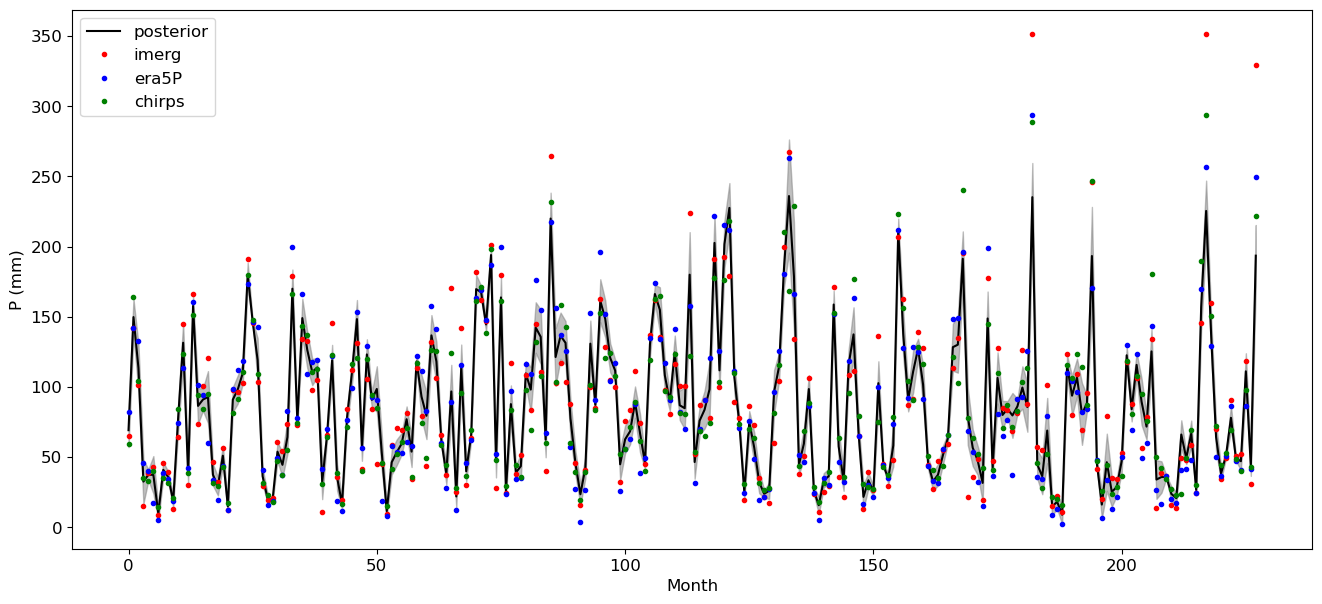

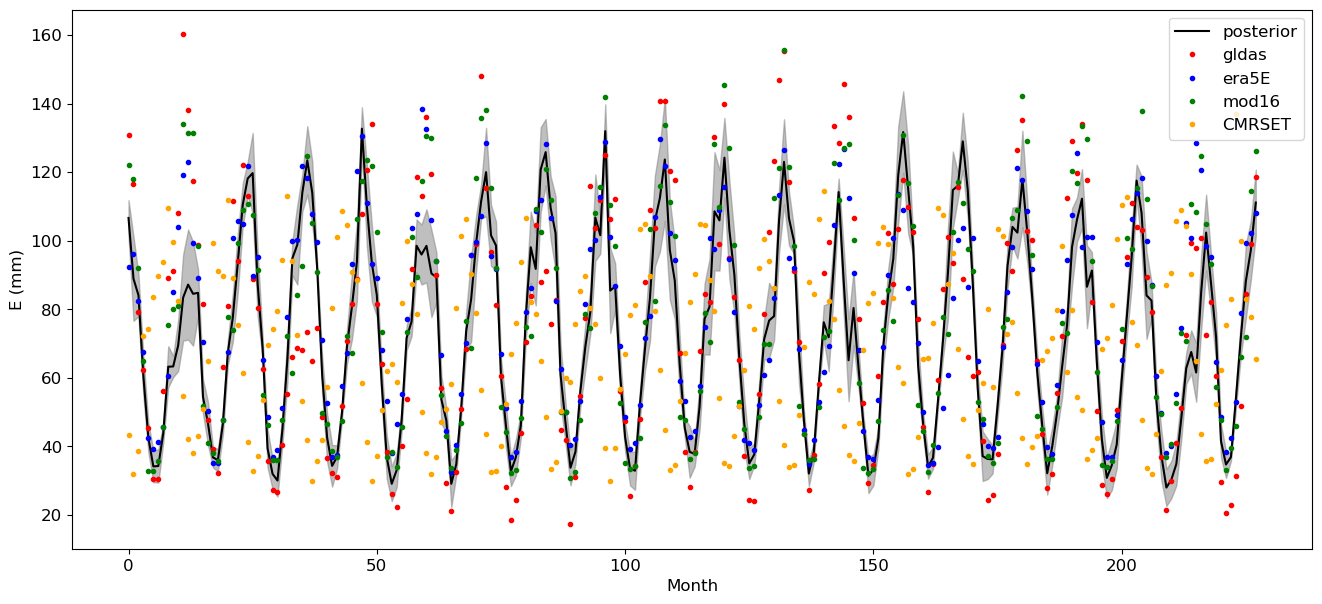

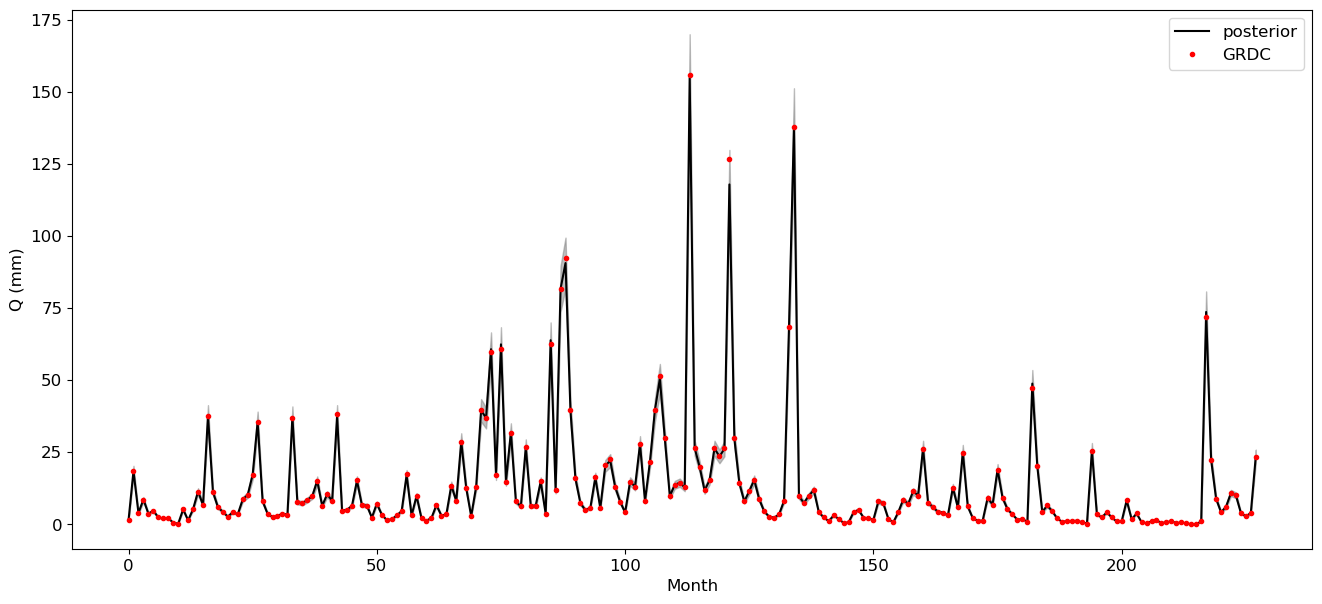

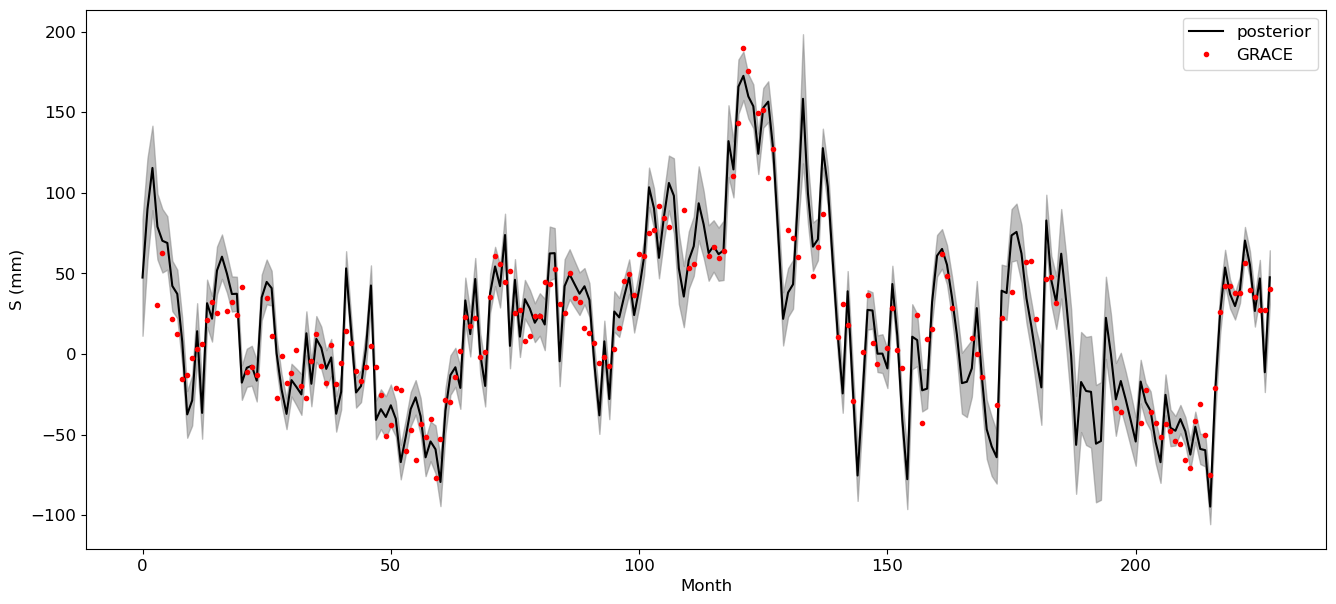

In [23]:
emptyP = np.full(len(mPostP), np.nan)
emptyQ = np.full(len(mPostQ), np.nan)
emptyS = np.full(len(mPostS), np.nan)

PlotPosterior("P (mm)", mPostP, vPostP, PObs1, PObs2, PObs3, emptyP,'imerg', 'era5P', 'chirps', '')

PlotPosterior("E (mm)", mPostE, vPostE, EObs1, EObs2, EObs3, EObs4,'gldas', 'era5E', 'mod16', 'CMRSET')

PlotPosterior("Q (mm)", mPostQ, vPostQ, QObs, emptyQ, emptyQ, emptyQ,'GRDC', '', '', '')

PlotPosterior("S (mm)", mPostS, vPostS, SObs, emptyS, emptyS, emptyS, 'GRACE', '', '', '')

In [1]:
summary = []

for name, v_prior, v_post in [
    ("P", vP, vPostP),
    ("E", vE, vPostE),
    ("Q", vQ, vPostQ),
    ("S", vS, vPostS),
]:
    v_prior = np.asarray(v_prior, dtype=float).flatten()
    v_post  = np.asarray(v_post, dtype=float).flatten()

    mean_prior = np.nanmean(v_prior)
    mean_post  = np.nanmean(v_post)
    abs_red = mean_prior - mean_post
    perc_red = (abs_red / mean_prior) * 100 if mean_prior != 0 else np.nan

    summary.append([name, mean_prior, mean_post, abs_red, perc_red])

df_summary = pd.DataFrame(
    summary,
    columns=[
        "Variable",
        "Mean prior variance",
        "Mean posterior variance",
        "Absolute reduction",
        "Percent reduction (%)"
    ]
)

print(df_summary)

for _, row in df_summary.iterrows():
    print(
        f"For {row['Variable']}, the mean variance decreased from "
        f"{row['Mean prior variance']:.4f} to {row['Mean posterior variance']:.4f}, "
        f"which is a reduction of {row['Percent reduction (%)']:.2f}%."
    )

NameError: name 'vP' is not defined

# Part 4: Budyko comparing

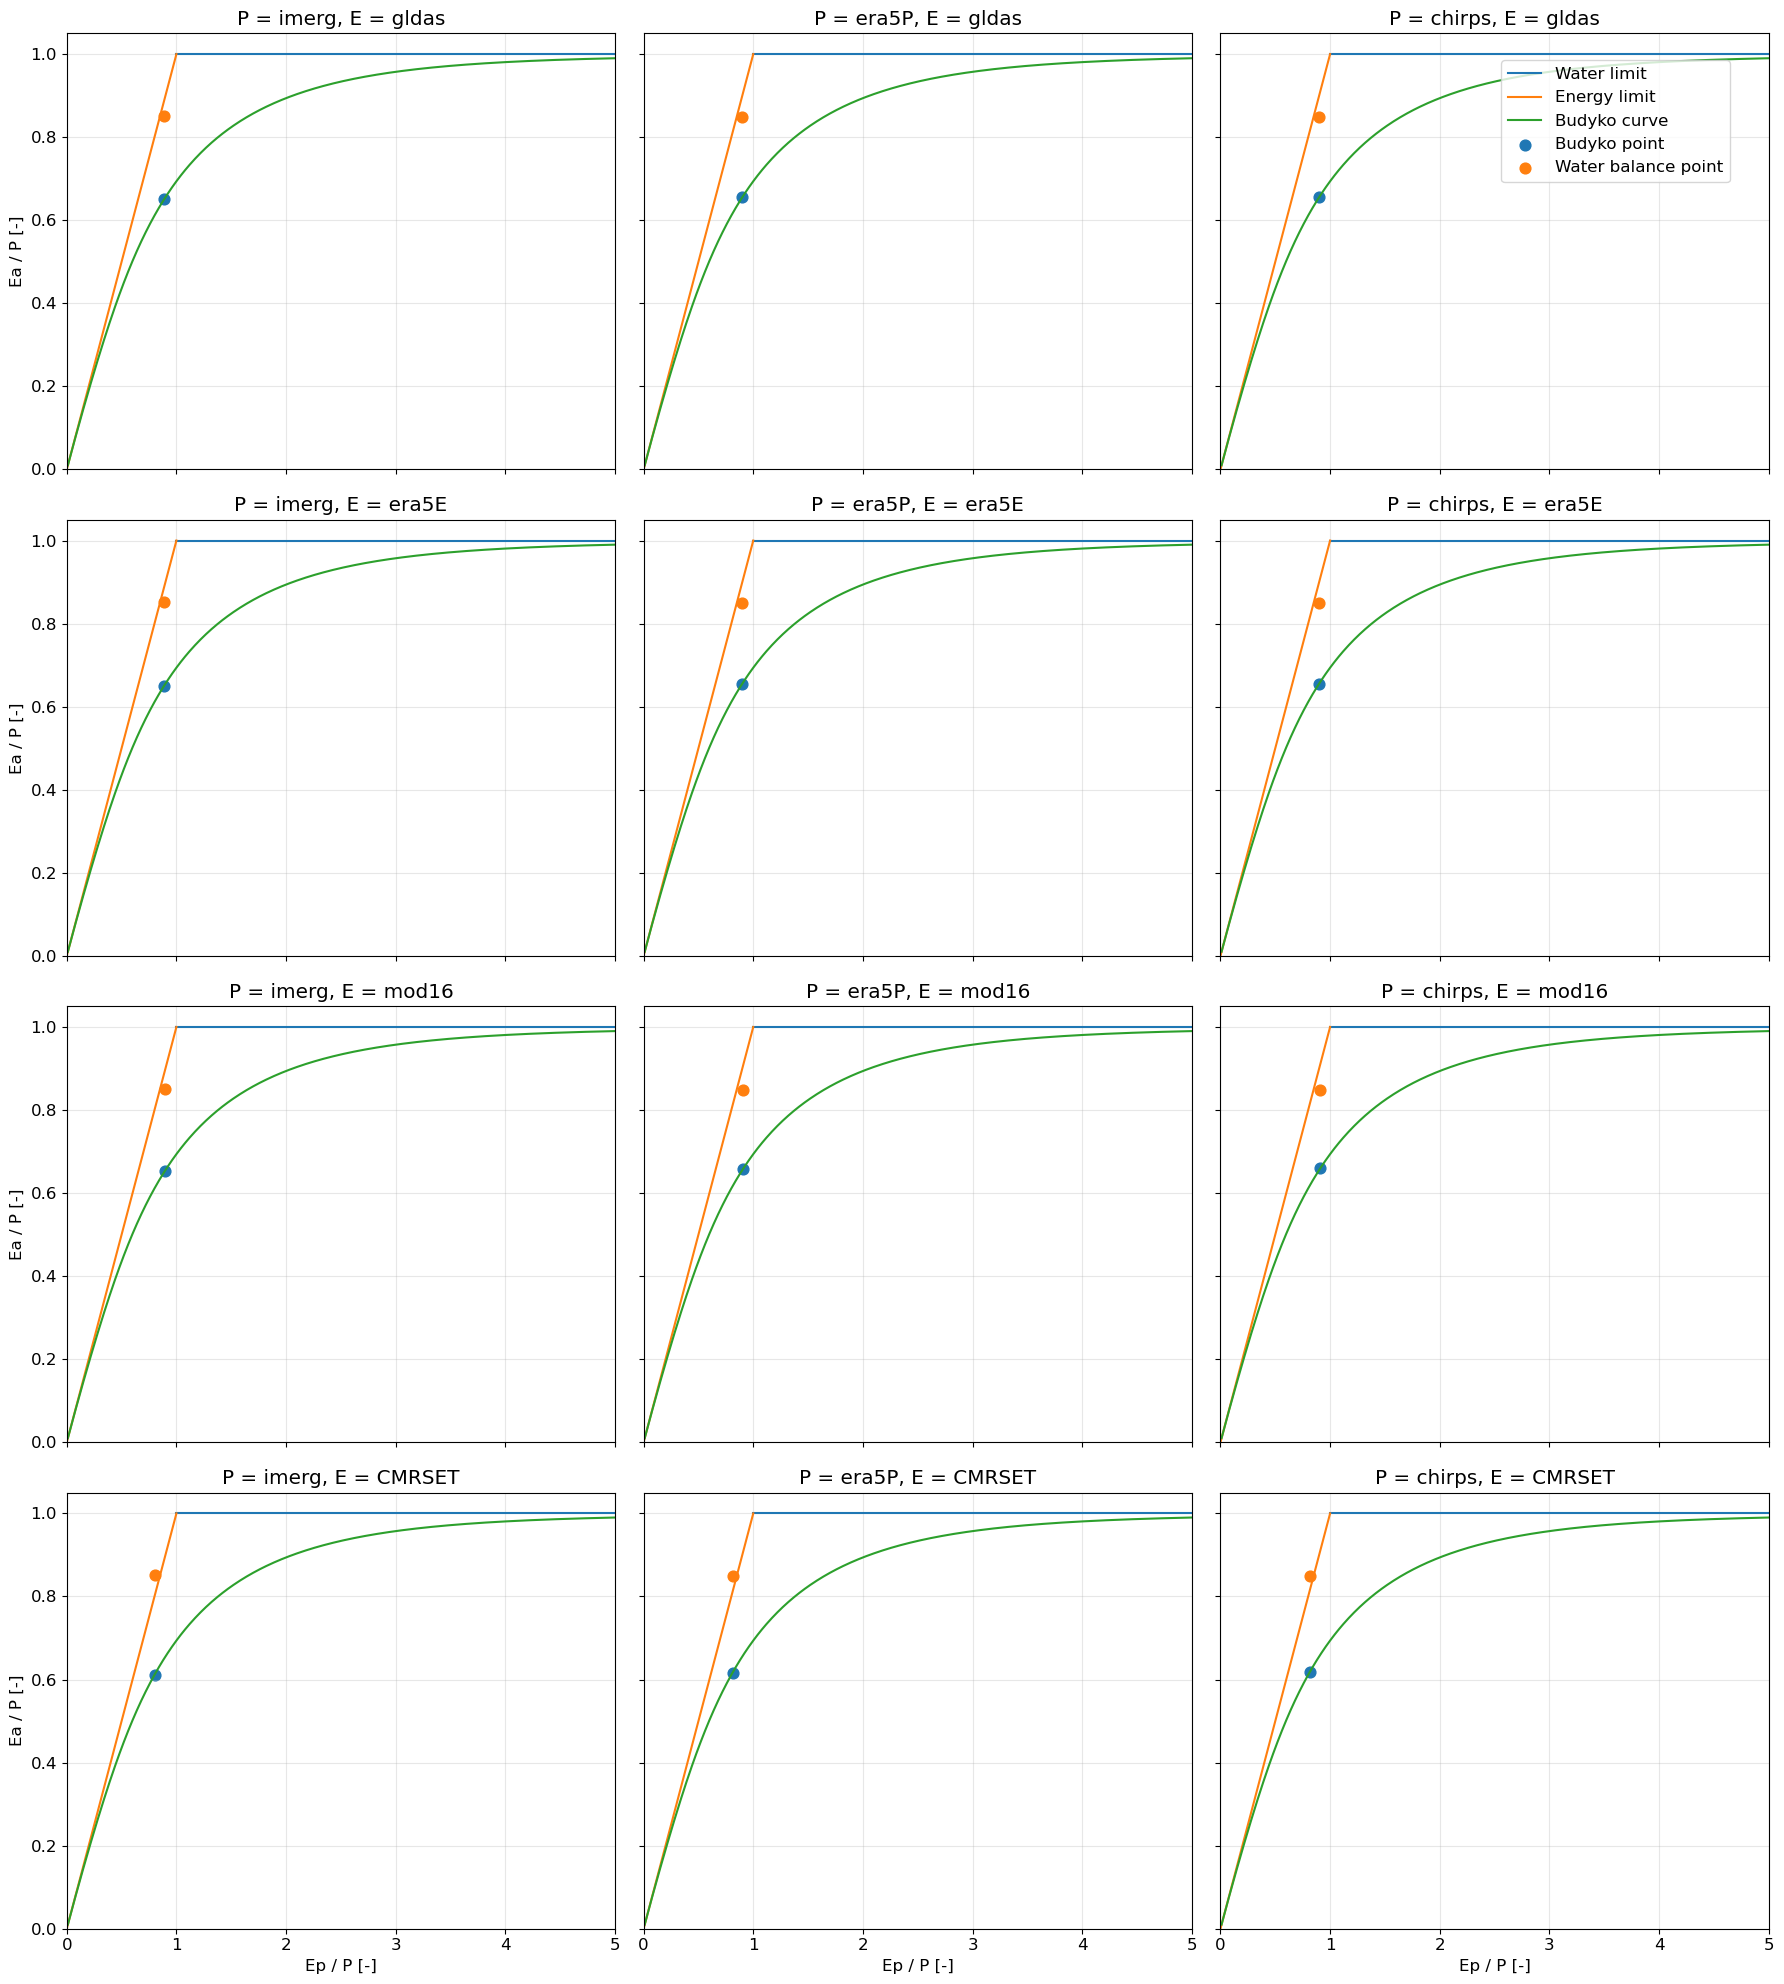

In [24]:
ep_p_curve = np.arange(0.01, 5.25, 0.01)
budyko_curve = np.sqrt(ep_p_curve * np.tanh(1 / ep_p_curve) * (1 - np.exp(-ep_p_curve)))

# Energy limit: Ea/P = Ep/P for Ep/P <= 1
ep_energy = np.array([0, 1])
ea_energy = np.array([0, 1])

# Water limit: Ea/P = 1 for Ep/P >= 1
ep_water = np.arange(1, 5.25, 0.01)
ea_water = np.ones_like(ep_water)

P = [PObs1, PObs2, PObs3]  
E = [EObs1, EObs2, EObs3, EObs4]

Plabel = ['imerg', 'era5P', 'chirps']
Elabel = ['gldas', 'era5E', 'mod16', 'CMRSET']

fig, ax = plt.subplots(nrows=len(E), ncols=len(P), figsize=(18, 20), sharex=True, sharey=True)

for e in range(len(E)):
    for p in range(len(P)):
        P_arr = np.asarray(P[p], dtype=float).flatten()
        E_arr = np.asarray(E[e], dtype=float).flatten()
        Q_arr = np.asarray(QObs, dtype=float).flatten()
        P_mean = np.nanmean(P_arr)
        E_mean = np.nanmean(E_arr)
        Q_mean = np.nanmean(Q_arr)

        # Aridity index
        EP_P = E_mean / P_mean
        B = np.sqrt(EP_P * np.tanh(1 / EP_P) * (1 - np.exp(-EP_P)))
        # Water balance evaporative index: Ea / P = 1 - Q/P
        WB = 1 - (Q_mean / P_mean)

        ax[e, p].plot(ep_water, ea_water, label='Water limit')
        ax[e, p].plot(ep_energy, ea_energy, label='Energy limit')
        ax[e, p].plot(ep_p_curve, budyko_curve, label='Budyko curve')
        ax[e, p].scatter(EP_P, B, s=60, label='Budyko point')
        ax[e, p].scatter(EP_P, WB, s=60, label='Water balance point')
        ax[e, p].set_title(f'P = {Plabel[p]}, E = {Elabel[e]}')
        ax[e, p].set_xlim(0, 5)
        ax[e, p].set_ylim(0, 1.05)
        ax[e, p].grid(True, alpha=0.3)
        if p == 0:
            ax[e, p].set_ylabel('Ea / P [-]')
        if e == len(E) - 1:
            ax[e, p].set_xlabel('Ep / P [-]')

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.97, 0.97))

plt.tight_layout()
plt.show()

In [25]:
for e in range(len(E)):
    for p in range(len(P)):
        P_arr = np.asarray(P[p], dtype=float).flatten()
        E_arr = np.asarray(E[e], dtype=float).flatten()
        Q_arr = np.asarray(QObs, dtype=float).flatten()

        P_mean = np.nanmean(P_arr)
        E_mean = np.nanmean(E_arr)
        Q_mean = np.nanmean(Q_arr)

        EP_P = E_mean / P_mean
        WB = 1 - (Q_mean / P_mean)

        print(f"P={Plabel[p]}, E={Elabel[e]} -> Pmean={P_mean:.2f}, Emean={E_mean:.2f}, Qmean={Q_mean:.2f}, Ep/P={EP_P:.3f}, WB={WB:.3f}")

P=imerg, E=gldas -> Pmean=86.64, Emean=76.88, Qmean=12.90, Ep/P=0.887, WB=0.851
P=era5P, E=gldas -> Pmean=85.57, Emean=76.88, Qmean=12.90, Ep/P=0.898, WB=0.849
P=chirps, E=gldas -> Pmean=85.28, Emean=76.88, Qmean=12.90, Ep/P=0.902, WB=0.849
P=imerg, E=era5E -> Pmean=86.64, Emean=76.75, Qmean=12.90, Ep/P=0.886, WB=0.851
P=era5P, E=era5E -> Pmean=85.57, Emean=76.75, Qmean=12.90, Ep/P=0.897, WB=0.849
P=chirps, E=era5E -> Pmean=85.28, Emean=76.75, Qmean=12.90, Ep/P=0.900, WB=0.849
P=imerg, E=mod16 -> Pmean=86.64, Emean=77.62, Qmean=12.90, Ep/P=0.896, WB=0.851
P=era5P, E=mod16 -> Pmean=85.57, Emean=77.62, Qmean=12.90, Ep/P=0.907, WB=0.849
P=chirps, E=mod16 -> Pmean=85.28, Emean=77.62, Qmean=12.90, Ep/P=0.910, WB=0.849
P=imerg, E=CMRSET -> Pmean=86.64, Emean=69.43, Qmean=12.90, Ep/P=0.801, WB=0.851
P=era5P, E=CMRSET -> Pmean=85.57, Emean=69.43, Qmean=12.90, Ep/P=0.811, WB=0.849
P=chirps, E=CMRSET -> Pmean=85.28, Emean=69.43, Qmean=12.90, Ep/P=0.814, WB=0.849
